# This script aims to test PS random-forest classification
- created on 8/22/2025;oh my god, it actullly past one-year, today **9/9/2026**.
- the demo test is set for AI Baten
- all tranin polygon samples were extract by previous years' habitat mapping

In [1]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import fiona
import rasterio
from rasterio.plot import show
from rasterio.mask import mask

import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
# Field station based polygons
output_polygons = r"C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Reneco/Vegetation Cover and Food Availability Studies/Trophic_survey_data_114_station_habitat_polygon.shp"

gdf = gpd.read_file(output_polygons)

print(gdf.head())

   Station       Lat      Lon Code             Habitat         Habitat_Fr  \
0  ALBALF1  33.20027 -4.03529  ALF  Alfah-grass steppe          Alfatière   
1  ALBALF2  33.25830 -3.98760  ALF  Alfah-grass steppe          Alfatière   
2  ALBALF3  33.29604 -3.94828  ALF  Alfah-grass steppe          Alfatière   
3  ALBLDD1  33.17201 -3.97828  WED      Drainage lines  Ligne de drainage   
4  ALBLDD2  33.21472 -3.91305  WED      Drainage lines  Ligne de drainage   

   Habitat_id                                           geometry  
0           1  POLYGON ((403496.987 3673952.652, 403496.987 3...  
1           1  POLYGON ((408002.954 3680343.513, 408002.954 3...  
2           1  POLYGON ((411703.536 3684493.853, 411703.536 3...  
3           2  POLYGON ((408781.606 3670768.334, 408781.606 3...  
4           2  POLYGON ((414904.920 3675448.628, 414904.920 3...  


In [4]:
# load all possible and avilable raster data
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
# csv:trainning table, extracted values from raster
df = pd.read_csv(ra_dir + 'Trophic survey_vegetation taxa cover_2016-2023_al_baten_rsvalues.csv')
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'

# Define paths to your input rasters
# raster dir and file path
fp_ref = ra_dir + '20250711_PS_8b_mosaic_ref.tif'
fp_mo = ra_dir + '20250711_PS_8b_mosaic.tif'
fp_vi = ra_dir + '20250711_PS_8b_mosaic_si.tif'
output_path = ra_dir + '20250711_PS_bands_si.tif'

In [ ]:
# different traning polygons
# AI_Baten_rd points_300mbuf_pg_inter.shp, with a 300m buffer, 213 features
# AI_Baten_rdpoints_100mbuf_pg_inter.shp, with a 100m buffer, 440 features

In [8]:
src1 = rasterio.open(fp_mo)
src2 = rasterio.open(fp_vi)
print(src1.meta)
print(src2.meta)

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 12850, 'height': 11619, 'count': 8, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 12850, 'height': 11619, 'count': 19, 'crs': CRS.from_epsg(32630), 'transform': Affine(3.0, 0.0, 393249.0,
       0.0, -3.0, 3691608.0)}


In [10]:
df1 = src2.read(1)

In [6]:
try:
    # Open the input rasters
    with rasterio.open(fp_mo) as src1:
        with rasterio.open(fp_vi) as src2:
            # Check if extents, resolutions, and CRS match (important for accurate combination)
            if src1.bounds != src2.bounds or src1.res != src2.res or src1.crs != src2.crs:
                print("Warning: Input rasters have different extents, resolutions, or CRS. Combination may not be accurate.")

            # Read all bands from each raster
            data1 = src1.read()  # Reads all bands into a (bands, rows, cols) array
            data2 = src2.read()

            # Combine the data arrays along the band dimension
            combined_data = np.concatenate((data1, data2), axis=0)

            # Update metadata for the output raster
            out_meta = src1.meta.copy()
            out_meta.update({
                "count": src1.count + src2.count,  # New number of bands
                "dtype": combined_data.dtype,      # Data type of the combined array
            })

            # Write the combined data to a new raster file
            with rasterio.open(output_path, "w", **out_meta) as dest:
                dest.write(combined_data)

    print(f"Successfully combined rasters and saved to: {output_path}")

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or processing raster files: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully combined rasters and saved to: W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/20250711_PS_bands_si.tif


In [12]:
dst = rasterio.open(output_path)
dst.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0.0,
 'width': 12850,
 'height': 11619,
 'count': 27,
 'crs': CRS.from_epsg(32630),
 'transform': Affine(3.0, 0.0, 393249.0,
        0.0, -3.0, 3691608.0)}

In [6]:
# read the shp traning polygons
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
shp_infp1 = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab.shp'
train_shp = gpd.read_file(shp_infp1)

In [17]:
train_shp.crs #4326
train_shp_prj = train_shp.to_crs("EPSG:32630")
train_shp_prj.crs

<Projected CRS: EPSG:32630>
Name: WGS 84 / UTM zone 30N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°W and 0°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Burkina Faso. Côte' Ivoire (Ivory Coast). Faroe Islands - offshore. France. Ghana. Gibraltar. Ireland - offshore Irish Sea. Mali. Mauritania. Morocco. Spain. United Kingdom (UK).
- bounds: (-6.0, 0.0, 0.0, 84.0)
Coordinate Operation:
- name: UTM zone 30N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# Define output path
shp_outfp1 = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab_prj.shp'
polygon = gpd.read_file(shp_outfp1)

# # Save file
# train_shp_prj.to_file(shp_outfp1, driver='Shapefile')

In [12]:
polygon.head(2)

,name_en,status,country,working_ar,working_re,owners,Habitat,geometry
0,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Alfah-grass steppe,"MULTIPOLYGON (((410763.051 3681639.538, 410816..."
1,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Reg,"MULTIPOLYGON (((410999.464 3681506.930, 410989..."


In [15]:
# --- 5. Export the updated GeoDataFrame to a shapefile ---
output_shp_path = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab_zonal.shp'
# print(f"\nExporting updated polygons to '{output_shp_path}'...")
# polygons.to_file(output_shp_path)
# print("Export complete.")
polygons = gpd.read_file(output_shp_path)
polygons.head(2)

,name_en,status,country,working_ar,working_re,owners,Habitat,band_1_mea,band_2_mea,band_3_mea,...,band_19_me,band_20_me,band_21_me,band_22_me,band_23_me,band_24_me,band_25_me,band_26_me,band_27_me,geometry
0,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Alfah-grass steppe,1189.839404,1485.846521,1973.197288,...,0.116586,-0.309944,-0.116586,0.791233,0.109599,1.264065,0.785220,0.785220,0.097881,"MULTIPOLYGON (((410763.051 3681639.538, 410816..."
1,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Reg,1173.532744,1465.264909,1948.444711,...,0.117145,-0.310844,-0.117145,0.790358,0.109748,1.265542,0.785571,0.785571,0.097458,"MULTIPOLYGON (((410999.464 3681506.930, 410989..."


In [23]:
# Define your file paths
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
raster_path = ra_dir + '20250711_PS_bands_si.tif'
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
polygon_path = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab_zonal.shp'

# 1. Load the polygon data (GeoDataFrame)
try:
    polygons = gpd.read_file(polygon_path)
    print("Successfully loaded polygons.")
except Exception as e:
    print(f"Error loading polygons: {e}")
    exit()

# 2. Open the multi-band raster file and get metadata
try:
    with rasterio.open(raster_path) as src:
        # Get essential metadata for zonal analysis
        raster_meta = src.meta
        raster_transform = src.transform
        raster_crs = src.crs

        print("Successfully opened raster and retrieved metadata.")

        # --- CRITICAL: Check and align the Coordinate Reference Systems (CRS) ---
        # The CRS of the polygons must match the CRS of the raster
        if polygons.crs != raster_crs:
            print(f"CRS mismatch detected. Reprojecting polygons from {polygons.crs} to {raster_crs}...")
            polygons.to_crs(raster_crs, inplace=True)
            print("Polygons have been reprojected.")
        else:
            print("CRS of polygons and raster are already aligned.")

        # 3. Iterate through each band to run zonal stats
        for band_index in range(1, src.count + 1):
            # Read a single band at a time
            band_data = src.read(band_index)
            print(f"Processing band {band_index}...")

            # Run zonal stats for the current band
            # We use a list of stats here to extract multiple metrics at once
            band_stats = zonal_stats(
                polygons,
                band_data,
                affine=raster_transform,
                stats=['min', 'mean', 'max', 'count'],
                nodata=raster_meta.get('nodata')
            )

            # Extract the mean values and add a new column to the GeoDataFrame
            mean_values = [d['mean'] for d in band_stats]
            polygons[f'band_{band_index}_mean'] = mean_values

            print(f"Band {band_index} analysis complete.")

    # 4. Print the updated GeoDataFrame to verify results
    print("\nZonal analysis complete. Updated GeoDataFrame head:")
    print(polygons.head())

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening raster file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Successfully loaded polygons.
Successfully opened raster and retrieved metadata.
CRS of polygons and raster are already aligned.
Processing band 1...
Band 1 analysis complete.
Processing band 2...
Band 2 analysis complete.
Processing band 3...
Band 3 analysis complete.
Processing band 4...
Band 4 analysis complete.
Processing band 5...
Band 5 analysis complete.
Processing band 6...
Band 6 analysis complete.
Processing band 7...
Band 7 analysis complete.
Processing band 8...
Band 8 analysis complete.
Processing band 9...
Band 9 analysis complete.
Processing band 10...
Band 10 analysis complete.
Processing band 11...
Band 11 analysis complete.
Processing band 12...
Band 12 analysis complete.
Processing band 13...
Band 13 analysis complete.
Processing band 14...
Band 14 analysis complete.
Processing band 15...
Band 15 analysis complete.
Processing band 16...
Band 16 analysis complete.
Processing band 17...
Band 17 analysis complete.
Processing band 18...
Band 18 analysis complete.
Process

In [25]:
zonal_shp = gpd.read_file(output_shp_path)
zonal_shp.head()

,name_en,status,country,working_ar,working_re,owners,Habitat,band_1_mea,band_2_mea,band_3_mea,...,band_19_me,band_20_me,band_21_me,band_22_me,band_23_me,band_24_me,band_25_me,band_26_me,band_27_me,geometry
0,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Alfah-grass steppe,1189.839404,1485.846521,1973.197288,...,0.116586,-0.309944,-0.116586,0.791233,0.109599,1.264065,0.785220,0.785220,0.097881,"MULTIPOLYGON (((410763.051 3681639.538, 410816..."
1,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Reg,1173.532744,1465.264909,1948.444711,...,0.117145,-0.310844,-0.117145,0.790358,0.109748,1.265542,0.785571,0.785571,0.097458,"MULTIPOLYGON (((410999.464 3681506.930, 410989..."
2,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Reg,1082.945141,1366.958958,1799.906956,...,0.120138,-0.305727,-0.120138,0.785610,0.108175,1.273329,0.787468,0.787468,0.090256,"MULTIPOLYGON (((416565.103 3685748.994, 416561..."
3,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Wadi,1277.354736,1567.012355,1993.606327,...,0.113349,-0.269499,-0.113349,0.796587,0.101418,1.256101,0.783129,0.783129,0.083832,"POLYGON ((416565.103 3685748.994, 416197.603 3..."
4,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Alfah-grass steppe,1092.937705,1387.897704,1829.668268,...,0.130348,-0.317215,-0.130348,0.769599,0.118011,1.300300,0.793903,0.793903,0.099317,"MULTIPOLYGON (((401173.129 3677181.058, 401165..."


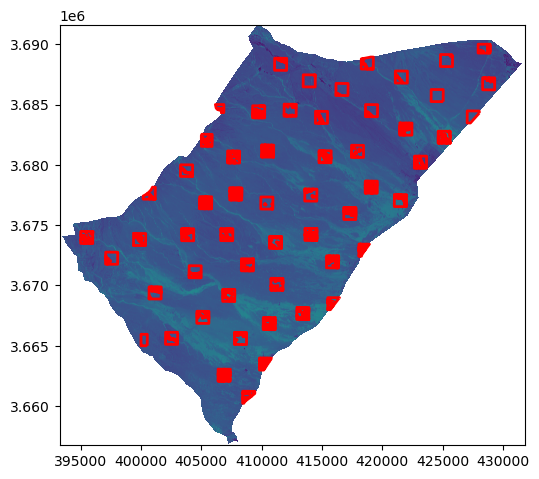

In [27]:
raster_path = ra_dir + '20250711_PS_bands_si.tif'
src = rasterio.open(raster_path)
fig, ax = plt.subplots(figsize=(6,6))
show(src, ax=ax, transform=src.transform)
zonal_shp.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2)
plt.show()

In [16]:
# output_shp_path = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab_zonal.shp'
# polygons = gpd.read_file(output_shp_path)

# --- NEW: Prepare data for classification ---
# It's a good practice to convert character-based class names to numerical IDs
# This is necessary for most machine learning models.
# Make sure to replace 'your_class_column' with the actual name of the column
# in your shapefile that contains the class names (e.g., 'Class_Name', 'Habitat').
polygons['habitat_id'], unique_classes = pd.factorize(polygons['Habitat'])
print(f"Converted character classes to numerical IDs: {unique_classes}")

Converted character classes to numerical IDs: Index(['Alfah-grass steppe', 'Reg', 'Wadi', 'Alluvial silt plain',
       'Tree farming', 'Salty steppe'],
      dtype='object')


In [18]:
# Save file
polygons.to_file(output_shp_path, driver='Shapefile')

In [19]:
polygons.head(2)

,name_en,status,country,working_ar,working_re,owners,Habitat,band_1_mea,band_2_mea,band_3_mea,...,band_20_me,band_21_me,band_22_me,band_23_me,band_24_me,band_25_me,band_26_me,band_27_me,geometry,habitat_id
0,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Alfah-grass steppe,1189.839404,1485.846521,1973.197288,...,-0.309944,-0.116586,0.791233,0.109599,1.264065,0.785220,0.785220,0.097881,"MULTIPOLYGON (((410763.051 3681639.538, 410816...",0
1,Al Baten,active,Morocco,Eastern Morocco,Missour,IFHC,Reg,1173.532744,1465.264909,1948.444711,...,-0.310844,-0.117145,0.790358,0.109748,1.265542,0.785571,0.785571,0.097458,"MULTIPOLYGON (((410999.464 3681506.930, 410989...",1


In [ ]:
# replacing nan to 0
raster_path = ra_dir + '20250711_PS_bands_si.tif'

In [22]:
import numpy as np
import rasterio
import geopandas as gpd
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm  # add a progress bar

# --- 1. Define File Paths ---
ra_dir = 'W:/GIS_Data/SatelliteImagery/HighResolution/Morocco/AI_Baten_2025_July_psscene_analytic_8b_sr_udm2/PSScene/'
shp_dir = 'C:/Users/PangY/OneDrive - Smithsonian Institution/Bustard/01_Data/Habitat mapping/'
raster_path = ra_dir + '20250711_PS_bands_si.tif'
shp_path = shp_dir + 'AI_Baten_rd points_500mbuf_polygon_lab_zonal.shp'
out_path = '20250711_PS_class.tif'

# --- 2. Load Raster and Training Data ---
try:
    with rasterio.open(raster_path) as src:
        raster_meta = src.meta.copy()
        raster_crs = src.crs
        image_data = src.read()
        print(f"Loaded raster with shape: {image_data.shape}")

    training_polygons = gpd.read_file(shp_path)
    LABEL_COLUMN = 'habitat_id'
    if LABEL_COLUMN not in training_polygons.columns:
        raise ValueError(f"Label column '{LABEL_COLUMN}' not found in training shapefile.")
    print(f"Loaded training polygons with CRS: {training_polygons.crs}")

except (rasterio.errors.RasterioIOError, ValueError) as e:
    print(f"Error loading data: {e}")
    exit()

# --- CRS Alignment ---
if training_polygons.crs != raster_crs:
    print("CRS mismatch detected. Reprojecting polygons...")
    training_polygons = training_polygons.to_crs(raster_crs)

# --- 3. Extract Pixel Values for Training ---
print("\nExtracting pixel values from training polygons...")
training_features = []
training_labels = []

for index, row in tqdm(training_polygons.iterrows(), total=len(training_polygons), desc="Polygons processed"):
    geom = [row['geometry']]
    try:
        with rasterio.open(raster_path) as src:
            out_image, _ = mask(src, geom, crop=True)

        # reshape: (bands, rows, cols) → (num_pixels, num_bands)
        pixels = out_image.reshape(out_image.shape[0], -1).T
        nodata = raster_meta.get('nodata', 0)
        mask_valid = ~np.all(pixels == nodata, axis=1)

        pixels = pixels[mask_valid]

        # --- Fix: Replace NaN with 0
        pixels = np.nan_to_num(pixels, nan=0)

        if pixels.size > 0:
            training_features.extend(pixels.tolist())
            training_labels.extend([row[LABEL_COLUMN]] * pixels.shape[0])

    except ValueError:
        print(f"Skipping polygon {index} (outside raster bounds)")
        continue

if not training_features:
    print("Error: No training data extracted.")
    exit()

training_features = np.array(training_features)
training_labels = np.array(training_labels)
print(f"Extracted {training_features.shape[0]} pixels across {len(np.unique(training_labels))} classes.")

# --- 4. Train Classifier ---
print("\nTraining Random Forest Classifier...")
classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
classifier.fit(training_features, training_labels)
print("Random Forest training complete.")

# --- 5. Classify the Entire Raster ---
print("\nClassifying the raster...")
classified_data = image_data.T.reshape(-1, image_data.shape[0])
prediction = classifier.predict(classified_data)
classified_raster = prediction.reshape(image_data.shape[1], image_data.shape[2]).astype(np.uint8)
print("Classification complete.")

# --- 6. Save Classified Raster ---
print("\nSaving classified raster...")
raster_meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 0
})
with rasterio.open(out_path, 'w', **raster_meta) as dst:
    dst.write(classified_raster, 1)
print(f"Saved classified raster: {out_path}")


Loaded raster with shape: (27, 11619, 12850)
Loaded training polygons with CRS: EPSG:32630

Extracting pixel values from training polygons...


Polygons processed: 100%|████████████████████████████████████████████████████████████| 152/152 [02:43<00:00,  1.07s/it]


Extracted 5780433 pixels across 6 classes.

Training Random Forest Classifier...
Random Forest training complete.

Classifying the raster...


ValueError: Input X contains NaN.
RandomForestClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values